In [1]:
import sys
import os

# This line lets your notebook find the 'src' directory relative to the notebooks folder
sys.path.append(os.path.abspath(os.path.join("..")))

import pandas as pd
from src.data_loader import load_and_merge_data

# Run our high-performance data loader
df = load_and_merge_data()


⏳ Loading train data...
⏳ Loading store metadata...
🔗 Merging datasets...
📉 Optimizing memory usage...
✅ Data loaded successfully! Final shape: (3000888, 10)


In [2]:
# Check 1: See information about data types and memory reduction
df.info()

# Check 2: Scan for missing value counts across columns
print("Missing values per column:\n", df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 10 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int32         
 1   date         datetime64[ns]
 2   store_nbr    int8          
 3   family       object        
 4   sales        float32       
 5   onpromotion  int16         
 6   city         object        
 7   state        object        
 8   type         object        
 9   cluster      int8          
dtypes: datetime64[ns](1), float32(1), int16(1), int32(1), int8(2), object(4)
memory usage: 148.8+ MB
Missing values per column:
 id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
city           0
state          0
type           0
cluster        0
dtype: int64


In [3]:
# Print unique categories for text columns to check for garbage characters
text_cols = ["family", "city", "state", "type"]

for col in text_cols:
    print(f"--- Unique values in '{col}' ({df[col].nunique()} total) ---")
    # Sort them to easily spot leading spaces, punctuation, or odd strings
    print(sorted(df[col].unique())[:10])  # Printing first 10 for brevity
    print("\n")


--- Unique values in 'family' (33 total) ---
['AUTOMOTIVE', 'BABY CARE', 'BEAUTY', 'BEVERAGES', 'BOOKS', 'BREAD/BAKERY', 'CELEBRATION', 'CLEANING', 'DAIRY', 'DELI']


--- Unique values in 'city' (22 total) ---
['Ambato', 'Babahoyo', 'Cayambe', 'Cuenca', 'Daule', 'El Carmen', 'Esmeraldas', 'Guaranda', 'Guayaquil', 'Ibarra']


--- Unique values in 'state' (16 total) ---
['Azuay', 'Bolivar', 'Chimborazo', 'Cotopaxi', 'El Oro', 'Esmeraldas', 'Guayas', 'Imbabura', 'Loja', 'Los Rios']


--- Unique values in 'type' (5 total) ---
['A', 'B', 'C', 'D', 'E']




In [4]:
# Check numerical ranges for impossible negative values
df[["sales", "onpromotion"]].describe()


,sales,onpromotion
count,3.000888e+06,3.000888e+06
mean,3.577758e+02,2.602770e+00
std,1.101998e+03,1.221888e+01
min,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00
50%,1.100000e+01,0.000000e+00
75%,1.958473e+02,0.000000e+00
max,1.247170e+05,7.410000e+02


In [5]:
# Calculate expected number of unique days vs actual unique days
min_date = df["date"].min()
max_date = df["date"].max()
expected_days = (max_date - min_date).days + 1
actual_days = df["date"].nunique()

print(f"Dataset Timeline: {min_date.date()} to {max_date.date()}")
print(f"Expected consecutive days: {expected_days}")
print(f"Actual unique days in data: {actual_days}")

if expected_days != actual_days:
    print(f"⚠️ WARNING: You are missing {expected_days - actual_days} days!")


Dataset Timeline: 2013-01-01 to 2017-08-15
Expected consecutive days: 1688
Actual unique days in data: 1684
⚠️ WARNING: You are missing 4 days!


In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join("..")))

import pandas as pd
from src.data_loader import load_and_merge_data, merge_oil_data

# Run Phase 1 data pipeline
df = load_and_merge_data()
df = merge_oil_data(df)

# Final Verification Checks
print("\n--- Final Integrity Check ---")
print(f"Total rows: {len(df)}")
print(f"Unique days: {df['date'].nunique()} (Should be exactly 1688!)")
print(f"Any remaining Nulls?\n{df.isnull().sum()}")


⏳ Loading train data...
🗓️ Repairing missing timeline gaps...
⏳ Loading store metadata...
🔗 Merging datasets...
% Optimizing memory usage...
✓ Data loaded successfully! Final shape: (3008016, 10)
⏳ Ingesting and treating oil prices...
✓ Oil price feature integrated cleanly.

--- Final Integrity Check ---
Total rows: 3008016
Unique days: 1688 (Should be exactly 1688!)
Any remaining Nulls?
date           0
store_nbr      0
family         0
id             0
sales          0
onpromotion    0
city           0
state          0
type           0
cluster        0
oil_price      0
dtype: int64


In [2]:
# Create temporary feature indicators for analysis
df['day_of_month'] = df['date'].dt.day
df['is_last_day'] = df['date'].dt.is_month_end

# Define payday: 15th OR the last day of the month
df['is_payday'] = (df['day_of_month'] == 15) | (df['is_last_day'] == True)

# Group by the payday flag and check average sales
payday_analysis = df.groupby('is_payday')['sales'].mean().reset_index()
print("--- Payday Sales Analysis ---")
print(payday_analysis)


--- Payday Sales Analysis ---
   is_payday       sales
0      False  356.536102
1       True  362.494904


C:\Users\adis2\AppData\Local\Temp\ipykernel_15780\3202327036.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weekly_profile, x='day_name', y='sales', palette='Blues_d')


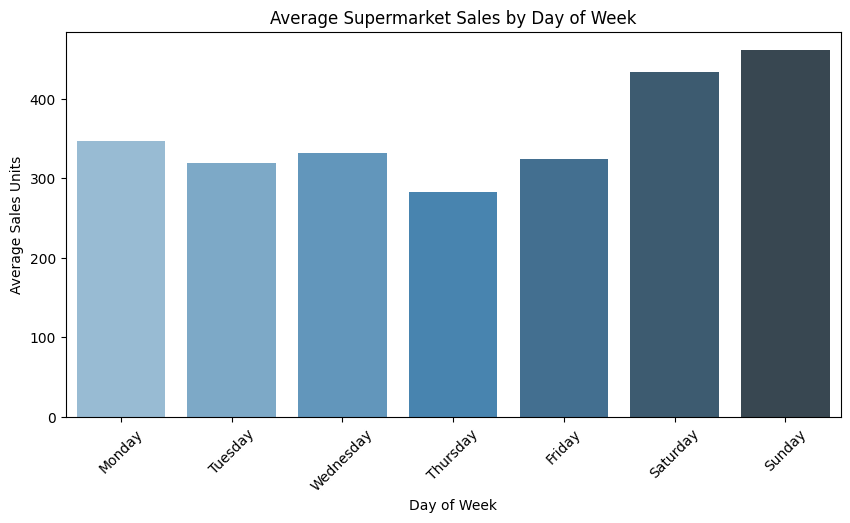

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract day of week (0 = Monday, 6 = Sunday)
df['day_of_week'] = df['date'].dt.dayofweek
df['day_name'] = df['date'].dt.day_name()

# Calculate mean sales per day of the week
weekly_profile = df.groupby(['day_of_week', 'day_name'])['sales'].mean().reset_index()

# Plot the weekly trend
plt.figure(figsize=(10, 5))
sns.barplot(data=weekly_profile, x='day_name', y='sales', palette='Blues_d')
plt.title('Average Supermarket Sales by Day of Week')
plt.ylabel('Average Sales Units')
plt.xlabel('Day of Week')
plt.xticks(rotation=45)
plt.show()


Pearson Correlation between Daily National Sales and Oil Price: -0.6191


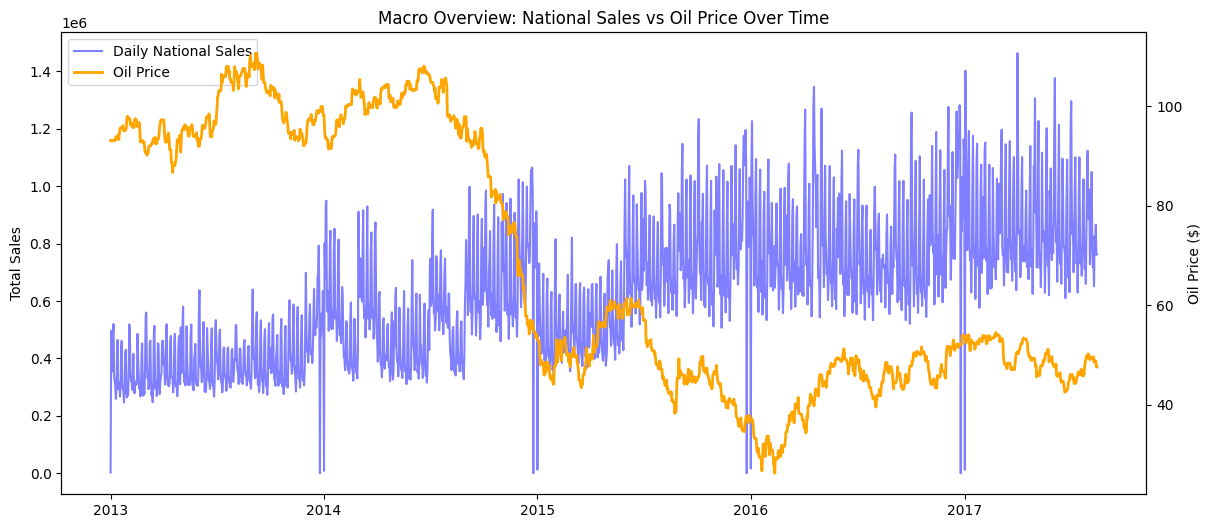

In [5]:
# Group by date to get total daily national sales and daily oil price
daily_macro = df.groupby('date').agg({'sales': 'sum', 'oil_price': 'first'}).reset_index()

# Calculate Pearson correlation coefficient
correlation = daily_macro['sales'].corr(daily_macro['oil_price'])
print(f"Pearson Correlation between Daily National Sales and Oil Price: {correlation:.4f}")

# Plot a rolling trend to see it visually
fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot Sales on the primary Y-axis
line1, = ax1.plot(daily_macro['date'], daily_macro['sales'], label='Daily National Sales', color='blue', alpha=0.5)
ax1.set_ylabel('Total Sales')

# Create a secondary Y-axis
ax2 = ax1.twinx()
line2, = ax2.plot(daily_macro['date'], daily_macro['oil_price'], label='Oil Price', color='orange', linewidth=2)
ax2.set_ylabel('Oil Price ($)')

# Combine legends from both axes into one box
lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title('Macro Overview: National Sales vs Oil Price Over Time')
plt.show()
